# GC Example 22: APOGEE Member Star Counts

**EPS Research — Milky Way GC Corpus v1.3.1**

APOGEE DR17 provides n_members — the number of member stars
with H-band spectroscopy. Higher counts = better chemistry statistics.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907765  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.1.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with APOGEE members: 72
N members range: 1 -- 1864

Top 10 by member count:
  NGC 5139     N=1864  [Fe/H]=-1.6  mass=364.0 x10^4 Msun
  NGC 6715     N=1809  [Fe/H]=-0.62  mass=178.0 x10^4 Msun
  NGC 6656     N= 412  [Fe/H]=-1.7  mass=47.6 x10^4 Msun
  NGC 5272     N= 299  [Fe/H]=-1.43  mass=41.0 x10^4 Msun
  NGC 104      N= 297  [Fe/H]=-0.74  mass=89.5 x10^4 Msun
  NGC 5904     N= 259  [Fe/H]=-1.21  mass=39.4 x10^4 Msun
  NGC 6121     N= 224  [Fe/H]=-1.07  mass=8.7 x10^4 Msun
  NGC 3201     N= 217  [Fe/H]=-1.39  mass=16.0 x10^4 Msun
  NGC 6397     N= 187  [Fe/H]=-2.02  mass=9.7 x10^4 Msun
  NGC 7078     N= 155  [Fe/H]=-2.29  mass=63.3 x10^4 Msun


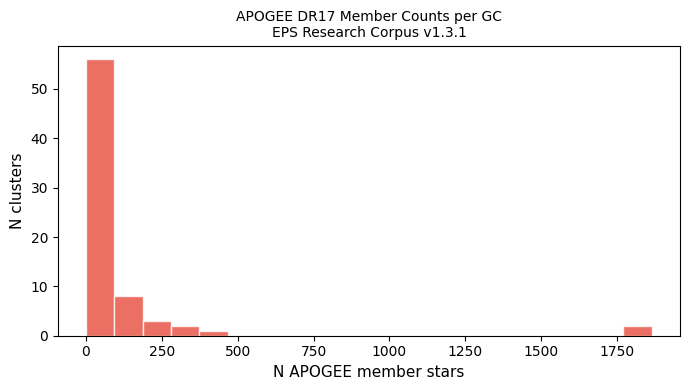

In [2]:
data=[(c['cluster_id'],c['apogee_dr17']['n_members'],
        c['apogee_dr17'].get('feh_apogee'),
        c['apogee_dr17'].get('mass_1e4_msun'))
      for c in clusters if c.get('apogee_dr17') and c['apogee_dr17'].get('n_members')]
n_members=[d[1] for d in data]
print(f"Clusters with APOGEE members: {len(data)}")
print(f"N members range: {min(n_members)} -- {max(n_members)}")
print(f"\nTop 10 by member count:")
for d in sorted(data,key=lambda x:-x[1])[:10]:
    print(f"  {d[0]:<12} N={d[1]:>4}  [Fe/H]={d[2]}  mass={d[3]} x10^4 Msun")
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(n_members,bins=20,color='#e74c3c',alpha=0.8,edgecolor='white')
ax.set_xlabel('N APOGEE member stars',fontsize=11); ax.set_ylabel('N clusters',fontsize=11)
ax.set_title('APOGEE DR17 Member Counts per GC\nEPS Research Corpus v1.3.1',fontsize=10)
plt.tight_layout(); plt.savefig('gc22_apogee_members.png',dpi=150,bbox_inches='tight'); plt.show()